In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
df = pd.read_csv("car_prediction_data.csv")

In [5]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [6]:
df.shape

(301, 9)

In [7]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [9]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [10]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [11]:
df.duplicated().sum()

np.int64(2)

In [12]:
df = df.drop_duplicates()

In [13]:
df.shape

(299, 9)

In [15]:
df['Car_Age'] = 2026 - df['Year']

In [16]:
df[['Year', 'Car_Age']].head()

,Year,Car_Age
0,2014,12
1,2013,13
2,2017,9
3,2011,15
4,2014,12


In [19]:
import seaborn as sns

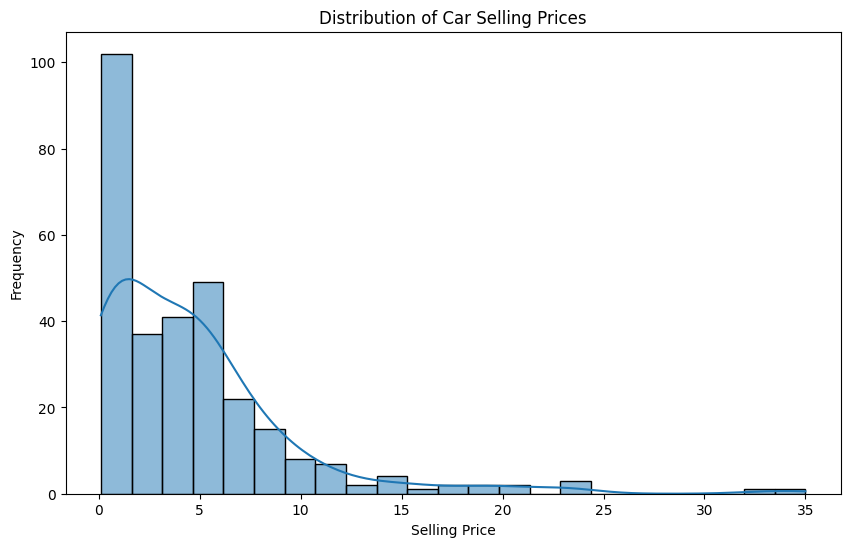

In [20]:
plt.figure(figsize=(10,6))

sns.histplot(df['Selling_Price'], kde=True)

plt.title('Distribution of Car Selling Prices')
plt.xlabel('Selling Price')
plt.ylabel('Frequency')

plt.show()

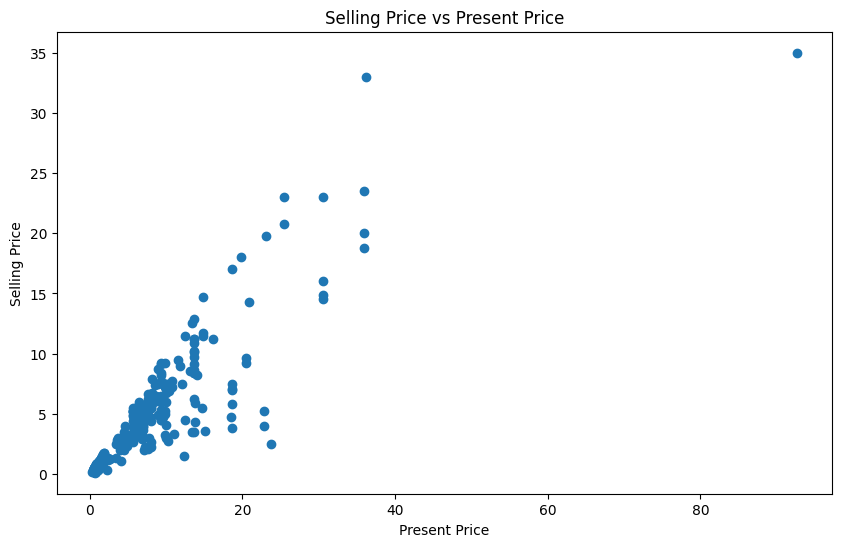

In [21]:
plt.figure(figsize=(10,6))

plt.scatter(df['Present_Price'], df['Selling_Price'])

plt.title('Selling Price vs Present Price')
plt.xlabel('Present Price')
plt.ylabel('Selling Price')

plt.show()

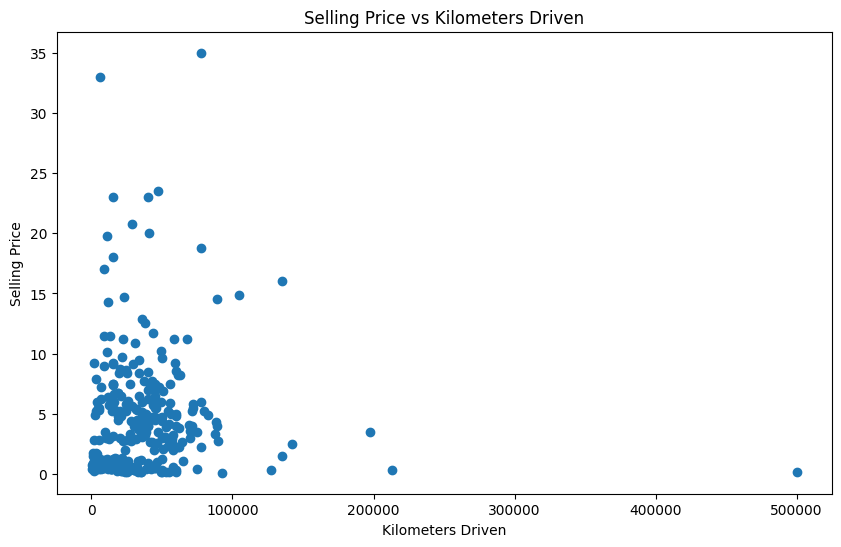

In [22]:
plt.figure(figsize=(10,6))

plt.scatter(df['Kms_Driven'], df['Selling_Price'])

plt.title('Selling Price vs Kilometers Driven')
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price')

plt.show()

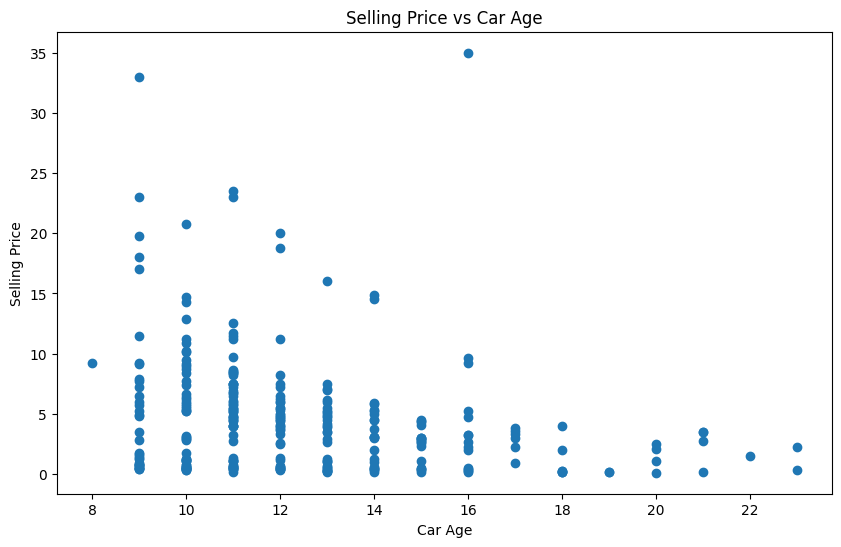

In [23]:
plt.figure(figsize=(10,6))

plt.scatter(df['Car_Age'], df['Selling_Price'])

plt.title('Selling Price vs Car Age')
plt.xlabel('Car Age')
plt.ylabel('Selling Price')

plt.show()

In [24]:
fuel_price = df.groupby('Fuel_Type')['Selling_Price'].mean()

print(fuel_price)

Fuel_Type
CNG        3.100000
Diesel    10.102759
Petrol     3.264184
Name: Selling_Price, dtype: float64


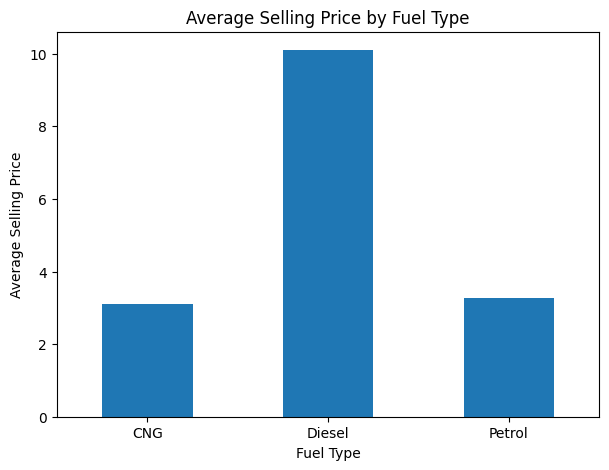

In [25]:
plt.figure(figsize=(7,5))

fuel_price.plot(kind='bar')

plt.title('Average Selling Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Average Selling Price')

plt.xticks(rotation=0)
plt.show()


In [26]:
transmission_price = df.groupby('Transmission')['Selling_Price'].mean()

print(transmission_price)

Transmission
Automatic    9.071795
Manual       3.917308
Name: Selling_Price, dtype: float64


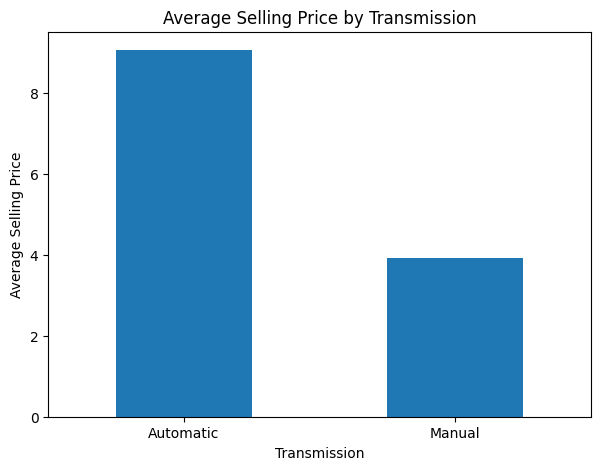

In [27]:
plt.figure(figsize=(7,5))

transmission_price.plot(kind='bar')

plt.title('Average Selling Price by Transmission')
plt.xlabel('Transmission')
plt.ylabel('Average Selling Price')

plt.xticks(rotation=0)
plt.show()

In [28]:
X = df.drop(['Selling_Price', 'Car_Name'], axis=1)
y = df['Selling_Price']

In [29]:
X.head()

,Year,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,2014,5.59,27000,Petrol,Dealer,Manual,0,12
1,2013,9.54,43000,Diesel,Dealer,Manual,0,13
2,2017,9.85,6900,Petrol,Dealer,Manual,0,9
3,2011,4.15,5200,Petrol,Dealer,Manual,0,15
4,2014,6.87,42450,Diesel,Dealer,Manual,0,12


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (239, 8)
Testing data: (60, 8)


In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [33]:
categorical_features = [
    'Fuel_Type',
    'Seller_Type',
    'Transmission'
]

In [34]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

In [36]:
linear_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

In [37]:
linear_model.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Fuel_Type', 'Seller_Type',
                                                   'Transmission'])])),
                ('model', LinearRegression())])

In [38]:
y_pred = linear_model.predict(X_test)

In [39]:
comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,8.99,7.501922
1,8.35,7.791521
2,0.45,1.366444
3,7.45,7.009419
4,5.25,11.163290
5,5.25,4.534102
6,5.85,8.492463
7,1.15,1.700782
8,9.25,8.824220
9,0.38,-0.963488


In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [41]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [42]:
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Mean Absolute Error: 1.47289241400347
Mean Squared Error: 6.370752956828819
Root Mean Squared Error: 2.5240350545958785
R² Score: 0.7528154215830766


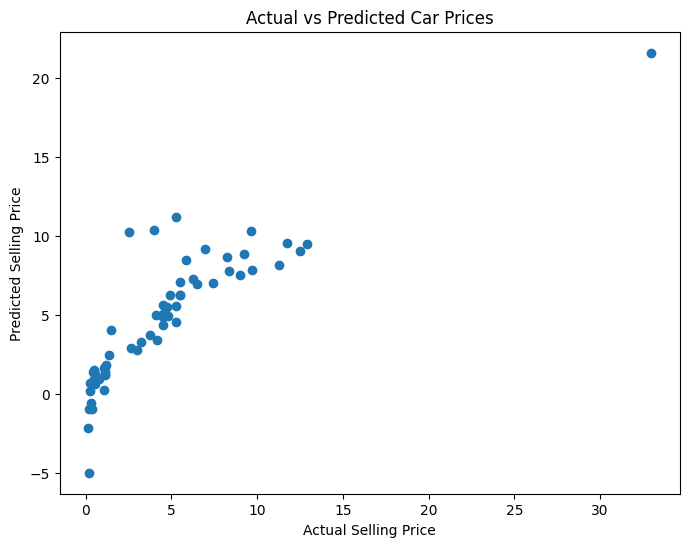

In [43]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual vs Predicted Car Prices')

plt.show()

In [44]:
from sklearn.ensemble import RandomForestRegressor

In [46]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

In [47]:
rf_model.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Fuel_Type', 'Seller_Type',
                                                   'Transmission'])])),
                ('model',
                 RandomForestRegressor(n_estimators=200, random_state=42))])

In [48]:
rf_pred = rf_model.predict(X_test)

In [49]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest MSE:", rf_mse)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R²:", rf_r2)

Random Forest MAE: 1.5387499999999996
Random Forest MSE: 13.76757425516668
Random Forest RMSE: 3.7104681989159642
Random Forest R²: 0.465819493998862


In [50]:
model_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae, rf_mae],
    'RMSE': [rmse, rf_rmse],
    'R2 Score': [r2, rf_r2]
})

model_comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.472892,2.524035,0.752815
1,Random Forest,1.538750,3.710468,0.465819


In [51]:
new_car = pd.DataFrame({
    'Year': [2018],
    'Present_Price': [8.0],
    'Kms_Driven': [30000],
    'Fuel_Type': ['Petrol'],
    'Seller_Type': ['Dealer'],
    'Transmission': ['Manual'],
    'Owner': [0],
    'Car_Age': [2026 - 2018]
})

In [52]:
predicted_price = rf_model.predict(new_car)

print("Predicted Selling Price:", predicted_price[0])

Predicted Selling Price: 6.1005
